# XQuality Machine32 — OLAF output evaluation with the NeoOLAF evaluator

This notebook evaluates the OLAF demo output you placed under:

```text
data/XQuality/Machine32
```

It uses the same XQuality/NeoOLAF domain evaluator path used in the robust ablation notebooks:

```python
evaluate_domain_kg(...)
build_neoolaf_json_method_config()
build_xquality_domain_config()
profile = "xquality_relaxed_recall"
```

The notebook:

1. finds the OLAF Excel output (`llm_alarm_triplets.xlsx`);
2. converts valid OLAF rows into a NeoOLAF-compatible `kg_inferred.json`;
3. evaluates it against the XQuality gold file;
4. computes the robust coverage/efficiency metrics;
5. optionally evaluates the latest native NeoOLAF final export as a reference;
6. saves CSV/JSON/plots under `examples/XQualityMachine32/runs/olaf_demo_same_evaluator_eval/`.

Important: the uploaded OLAF Excel file contains many rows with `?` as source/target. Those are reported separately and skipped for the NeoOLAF evaluator, because they are not evaluable triples.

In [1]:
from pathlib import Path
import sys
import json
import math
import re
import zipfile
import shutil
from typing import Any

import pandas as pd
from IPython.display import display

## 1. Project root and path configuration

In [2]:
def find_project_root(start: str | Path | None = None) -> Path:
    start = Path(start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src" / "neoolaf").exists():
            return p
    for p in candidates:
        if (p / "pyproject.toml").exists() and (p / "examples" / "XQualityMachine32").exists():
            return p
    raise RuntimeError("Could not find NeoOLAF project root. Run this notebook from inside the NeoOLAF repository.")

PROJECT_ROOT = find_project_root()
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

EXAMPLE_ROOT = PROJECT_ROOT / "examples" / "XQualityMachine32"
RUNS_ROOT = EXAMPLE_ROOT / "runs"
MACHINE32_DIR = PROJECT_ROOT / "data" / "XQuality" / "Machine32"

GOLD_PATH = PROJECT_ROOT / "data" / "XQuality" / "Examples" / "XQuality_all_triplets_flat_en.json"
PROFILE = "xquality_relaxed_recall"

OUTPUT_DIR = RUNS_ROOT / "olaf_demo_same_evaluator_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("MACHINE32_DIR:", MACHINE32_DIR)
print("GOLD_PATH:", GOLD_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not GOLD_PATH.exists():
    raise FileNotFoundError(f"Gold file not found: {GOLD_PATH}")
if not MACHINE32_DIR.exists():
    raise FileNotFoundError(f"Machine32 data folder not found: {MACHINE32_DIR}")

PROJECT_ROOT: C:\Users\henri\Documents\git\post-doc\NeoOLAF
MACHINE32_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32
GOLD_PATH: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Examples\XQuality_all_triplets_flat_en.json
OUTPUT_DIR: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval


## 2. Locate or extract OLAF demo files

In [3]:
# If you copied OLAF_DEMO.zip into data/XQuality/Machine32, this cell can extract it automatically.
# If you already extracted/copied the folder contents, it will simply find the files.

AUTO_EXTRACT_ZIP = True

candidate_zips = list(MACHINE32_DIR.rglob("OLAF_DEMO.zip")) + list(MACHINE32_DIR.rglob("olaf_demo.zip"))
if AUTO_EXTRACT_ZIP and candidate_zips:
    zip_path = candidate_zips[0]
    extract_dir = MACHINE32_DIR / "OLAF_DEMO"
    if not (extract_dir / "output" / "llm_alarm_triplets.xlsx").exists():
        print("Extracting:", zip_path, "->", extract_dir)
        extract_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_dir)

def first_match(root: Path, patterns: list[str]) -> Path | None:
    for pattern in patterns:
        matches = sorted(root.rglob(pattern))
        if matches:
            return matches[0]
    return None

OLAF_XLSX = first_match(MACHINE32_DIR, ["llm_alarm_triplets.xlsx", "*triplet*.xlsx", "*triple*.xlsx"])
OLAF_TTL = first_match(MACHINE32_DIR, ["llm_alarm_ontology.ttl", "*ontology*.ttl"])

print("OLAF_XLSX:", OLAF_XLSX)
print("OLAF_TTL:", OLAF_TTL)

if OLAF_XLSX is None or not OLAF_XLSX.exists():
    raise FileNotFoundError(
        "Could not find OLAF Excel output. Expected something like "
        "data/XQuality/Machine32/**/llm_alarm_triplets.xlsx"
    )

OLAF_XLSX: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_triplets.xlsx
OLAF_TTL: C:\Users\henri\Documents\git\post-doc\NeoOLAF\data\XQuality\Machine32\OLAF\output\llm_alarm_ontology.ttl


## 3. Import the NeoOLAF evaluator

In [4]:
from neoolaf.evaluation.domains.xquality import (
    build_neoolaf_json_method_config,
    build_xquality_domain_config,
)
from neoolaf.evaluation.runners.evaluate_domain_kg import EvaluationInput, evaluate_domain_kg

print("NeoOLAF evaluator imported successfully.")

NeoOLAF evaluator imported successfully.


## 4. Helper functions: OLAF Excel → NeoOLAF-compatible export

In [5]:
XQUALITY_RELATIONS = {"TRIGGERS", "CAUSES", "REQUIRES", "HANDLED_BY", "REFERENCES"}

# This optional map is deliberately conservative. The evaluator already maps
# labels such as "cause" and "requires" internally. Keep this disabled unless
# you want a manually forced OLAF-to-XQuality relation mapping.
USE_CUSTOM_RELATION_MAPPING = False
CUSTOM_RELATION_MAP = {
    # "cause": "CAUSES",
    # "has cause": "TRIGGERS",
    # "requires action": "REQUIRES",
    # "enable to": "REQUIRES",
    # "stop": "CAUSES",
}

def clean_text(value: Any) -> str:
    if value is None:
        return ""
    if isinstance(value, float) and math.isnan(value):
        return ""
    text = str(value).strip()
    text = re.sub(r"\s+", " ", text)
    return text

def is_missing_node(value: Any) -> bool:
    text = clean_text(value)
    return text == "" or text in {"?", "??", "???", "-", "_", "nan", "NaN", "None", "null"}

def pick_column(df: pd.DataFrame, candidates: list[str]) -> str:
    normalized = {re.sub(r"[^a-z0-9]+", "", c.lower()): c for c in df.columns}
    for cand in candidates:
        key = re.sub(r"[^a-z0-9]+", "", cand.lower())
        if key in normalized:
            return normalized[key]
    raise ValueError(f"Could not find any of columns {candidates}. Available columns: {list(df.columns)}")

def load_olaf_excel(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    xls = pd.ExcelFile(path)
    frames = []
    for sheet in xls.sheet_names:
        df = pd.read_excel(path, sheet_name=sheet)
        df["__sheet__"] = sheet
        frames.append(df)
    out = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    out["__row_index__"] = range(len(out))
    return out

def normalize_relation_label(label: str) -> str:
    label = clean_text(label)
    if USE_CUSTOM_RELATION_MAPPING:
        mapped = CUSTOM_RELATION_MAP.get(label.lower())
        if mapped:
            return mapped
    return label

def olaf_excel_to_neoolaf_triples(df: pd.DataFrame) -> tuple[list[dict[str, Any]], pd.DataFrame, pd.DataFrame]:
    source_col = pick_column(df, ["Source Node", "source", "subject", "head", "s"])
    target_col = pick_column(df, ["Target Node", "target", "object", "tail", "o"])
    relation_col = pick_column(df, ["Relation", "predicate", "relation", "p"])

    valid_rows = []
    skipped_rows = []
    triples = []
    seen_keys = set()

    for _, row in df.iterrows():
        source = clean_text(row.get(source_col))
        target = clean_text(row.get(target_col))
        relation = clean_text(row.get(relation_col))

        reason = None
        if is_missing_node(source):
            reason = "missing_source"
        elif is_missing_node(target):
            reason = "missing_target"
        elif is_missing_node(relation):
            reason = "missing_relation"

        row_dict = row.to_dict()
        row_dict["normalized_source"] = source
        row_dict["normalized_target"] = target
        row_dict["normalized_relation"] = relation

        if reason is not None:
            row_dict["skip_reason"] = reason
            skipped_rows.append(row_dict)
            continue

        relation_out = normalize_relation_label(relation)
        key = (source.lower(), relation_out.lower(), target.lower())
        if key in seen_keys:
            row_dict["skip_reason"] = "duplicate_after_normalization"
            skipped_rows.append(row_dict)
            continue
        seen_keys.add(key)

        triple = {
            "subject": {"label": source},
            "predicate": {"label": relation_out},
            "object": {"label": target},
            "justification": "",
            "chunk_id": "",
            "confidence": None,
            "raw": {
                "source_file": str(OLAF_XLSX),
                "sheet": row.get("__sheet__"),
                "row_index": int(row.get("__row_index__", -1)),
                "source_col": source_col,
                "target_col": target_col,
                "relation_col": relation_col,
                "source": source,
                "target": target,
                "relation": relation,
                "relation_after_optional_mapping": relation_out,
            },
        }
        triples.append(triple)
        row_dict["triple_key"] = " | ".join(key)
        valid_rows.append(row_dict)

    valid_df = pd.DataFrame(valid_rows)
    skipped_df = pd.DataFrame(skipped_rows)
    return triples, valid_df, skipped_df

def save_json(path: str | Path, data: Any) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(data, handle, ensure_ascii=False, indent=2, default=str)

def write_neoolaf_export_folder(triples: list[dict[str, Any]], out_dir: str | Path, document_id: str = "xquality") -> Path:
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    kg = {
        "document_id": document_id,
        "triples": triples,
        "metadata": {
            "source": "OLAF_DEMO Excel output",
            "source_xlsx": str(OLAF_XLSX),
            "profile_intended_for_evaluation": PROFILE,
            "usable_triple_count": len(triples),
            "relation_mapping_mode": "custom" if USE_CUSTOM_RELATION_MAPPING else "as_is_evaluator_builtin",
        },
    }
    save_json(out_dir / "kg_inferred.json", kg)
    save_json(out_dir / "triples.json", triples)
    return out_dir / "kg_inferred.json"

## 5. Convert OLAF output

In [6]:
olaf_raw_df = load_olaf_excel(OLAF_XLSX)
olaf_triples, olaf_valid_df, olaf_skipped_df = olaf_excel_to_neoolaf_triples(olaf_raw_df)

OLAF_EXPORT_DIR = OUTPUT_DIR / "normalized_inputs" / "olaf_demo_xlsx"
OLAF_KG_PATH = write_neoolaf_export_folder(olaf_triples, OLAF_EXPORT_DIR)

olaf_raw_df.to_csv(OUTPUT_DIR / "olaf_raw_rows.csv", index=False)
olaf_valid_df.to_csv(OUTPUT_DIR / "olaf_valid_triples.csv", index=False)
olaf_skipped_df.to_csv(OUTPUT_DIR / "olaf_skipped_rows.csv", index=False)

print("Raw Excel rows:", len(olaf_raw_df))
print("Usable triples:", len(olaf_triples))
print("Skipped rows:", len(olaf_skipped_df))
print("Wrote:", OLAF_KG_PATH)

display(olaf_valid_df.head(20))
if len(olaf_skipped_df):
    print("Skipped row reasons:")
    display(olaf_skipped_df["skip_reason"].value_counts().to_frame("count"))

Raw Excel rows: 82
Usable triples: 11
Skipped rows: 71
Wrote: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\normalized_inputs\olaf_demo_xlsx\kg_inferred.json


,Source Node,Target Node,Relation,__sheet__,__row_index__,normalized_source,normalized_target,normalized_relation,triple_key
0,M3,error code,begin,Sheet,71,M3,error code,begin,m3 | begin | error code
1,error code,door,stop,Sheet,72,error code,door,stop,error code | stop | door
2,error code,stop at end of cycle,stop at,Sheet,73,error code,stop at end of cycle,stop at,error code | stop at | stop at end of cycle
3,spindle synchronization,spindle synchronization,stopped,Sheet,74,spindle synchronization,spindle synchronization,stopped,spindle synchronization | stopped | spindle sy...
4,stop at end of cycle,Fanuc CNC series,stop,Sheet,75,stop at end of cycle,Fanuc CNC series,stop,stop at end of cycle | stop | fanuc cnc series
5,stop at end of cycle,door,stop,Sheet,76,stop at end of cycle,door,stop,stop at end of cycle | stop | door
6,stop at end of cycle,stop at end of cycle,stops,Sheet,77,stop at end of cycle,stop at end of cycle,stops,stop at end of cycle | stops | stop at end of ...
7,tool,"AXIS <X, Z, Y>",enable to,Sheet,78,tool,"AXIS <X, Z, Y>",enable to,"tool | enable to | axis <x, z, y>"
8,tool,input X4.3,enable to,Sheet,79,tool,input X4.3,enable to,tool | enable to | input x4.3
9,tool,spindle synchronization,enable to,Sheet,80,tool,spindle synchronization,enable to,tool | enable to | spindle synchronization


Skipped row reasons:


,count
skip_reason,
missing_source,71


## 6. Evaluation helpers

`raw_triple_count_for_efficiency` can mean two things for OLAF:

- `usable_triples`: only valid triples passed to the NeoOLAF evaluator.
- `all_excel_rows`: all rows emitted by OLAF, including `?` source/target rows.

The notebook reports both, but the main comparable score uses `usable_triples`, because that is the actual KG given to the evaluator. The `all_rows` variant is stricter and treats invalid rows as output noise.

In [7]:
def safe_div(n, d, default=0.0):
    try:
        n = float(n or 0.0)
        d = float(d or 0.0)
    except Exception:
        return default
    if d == 0:
        return default
    return n / d

def harmonic_mean(vals, default=0.0):
    vals2 = []
    for v in vals:
        try:
            x = float(v or 0.0)
        except Exception:
            return default
        if x <= 0 or not math.isfinite(x):
            return default
        vals2.append(x)
    if not vals2:
        return default
    return len(vals2) / sum(1.0 / x for x in vals2)

def fbeta(precision_like, recall_like, beta=1.0):
    p = float(precision_like or 0.0)
    r = float(recall_like or 0.0)
    if p <= 0 or r <= 0:
        return 0.0
    b2 = beta ** 2
    return (1 + b2) * p * r / ((b2 * p) + r)

def add_robust_metrics(row: dict[str, Any], raw_triple_count_for_efficiency: int, prefix: str = "") -> dict[str, Any]:
    tp = row.get("relation_tp", 0)
    gold = row.get("gold_relations_seen_by_evaluator", 0)
    entity_f1 = row.get("entity_f1", 0.0)

    coverage = safe_div(tp, gold)
    efficiency = safe_div(tp, raw_triple_count_for_efficiency)
    ce_f1 = harmonic_mean([coverage, efficiency])
    ce_f05 = fbeta(efficiency, coverage, beta=0.5)
    entity_balanced_f1 = harmonic_mean([ce_f1, entity_f1])
    entity_balanced_f05 = harmonic_mean([ce_f05, entity_f1])

    row[f"{prefix}gold_relation_coverage"] = coverage
    row[f"{prefix}raw_output_efficiency"] = efficiency
    row[f"{prefix}coverage_efficiency_f1"] = ce_f1
    row[f"{prefix}coverage_efficiency_f05"] = ce_f05
    row[f"{prefix}entity_relation_balanced_f1"] = entity_balanced_f1
    row[f"{prefix}entity_adjusted_ce_f05"] = entity_balanced_f05
    row[f"{prefix}overgeneration_factor"] = safe_div(raw_triple_count_for_efficiency, tp, default=float("inf") if tp == 0 and raw_triple_count_for_efficiency else 0.0)
    return row

def flatten_eval_summary(
    summary: dict[str, Any],
    *,
    series: str,
    layer_name: str,
    source_folder: str | Path,
    normalized_input_folder: str | Path,
    raw_excel_row_count: int | None = None,
    usable_triple_count: int | None = None,
) -> dict[str, Any]:
    entity = summary.get("entity", {}) or {}
    relation = summary.get("relation", {}) or {}

    row = {
        "series": series,
        "layer_name": layer_name,
        "profile": summary.get("profile", PROFILE),
        "source_folder": str(source_folder),
        "normalized_input_folder": str(normalized_input_folder),
        "raw_excel_row_count": raw_excel_row_count,
        "usable_triple_count": usable_triple_count,
        "raw_triple_count": usable_triple_count,
        "pred_relations_seen_by_evaluator": summary.get("pred_relations_count", 0),
        "gold_relations_seen_by_evaluator": summary.get("gt_relations_count", 0),
        "pred_entities_seen_by_evaluator": summary.get("pred_entities_count", 0),
        "gold_entities_seen_by_evaluator": summary.get("gt_entities_count", 0),
        "entity_tp": entity.get("tp", 0),
        "entity_fp": entity.get("fp", 0),
        "entity_fn": entity.get("fn", 0),
        "entity_precision": entity.get("precision", 0.0),
        "entity_recall": entity.get("recall", 0.0),
        "entity_f1": entity.get("f1", 0.0),
        "relation_tp": relation.get("tp", 0),
        "relation_fp": relation.get("fp", 0),
        "relation_fn": relation.get("fn", 0),
        "relation_precision": relation.get("precision", 0.0),
        "relation_recall": relation.get("recall", 0.0),
        "relation_f1": relation.get("f1", 0.0),
    }

    if usable_triple_count is not None:
        add_robust_metrics(row, usable_triple_count, prefix="")
    if raw_excel_row_count is not None:
        add_robust_metrics(row, raw_excel_row_count, prefix="all_rows_")

    return row

def per_relation_rows(summary: dict[str, Any], *, series: str, layer_name: str) -> list[dict[str, Any]]:
    rows = []
    pr = summary.get("per_relation", []) or []
    if isinstance(pr, dict):
        iterator = []
        for rel, metrics in pr.items():
            if isinstance(metrics, dict):
                iterator.append({"relation": rel, **metrics})
    else:
        iterator = [x for x in pr if isinstance(x, dict)]

    for item in iterator:
        tp = item.get("tp", 0)
        gt_count = item.get("gt_count", 0)
        pred_count = item.get("pred_count", 0)
        coverage = safe_div(tp, gt_count)
        canonical_eff = safe_div(tp, pred_count)
        rows.append({
            "series": series,
            "layer_name": layer_name,
            **item,
            "relation_coverage": coverage,
            "canonical_output_efficiency": canonical_eff,
            "coverage_canonical_efficiency_f1": harmonic_mean([coverage, canonical_eff]),
        })
    return rows

def evaluate_kg_folder(
    *,
    kg_path: str | Path,
    eval_output_dir: str | Path,
    source_folder: str | Path,
    normalized_input_folder: str | Path,
    series: str,
    layer_name: str,
    raw_excel_row_count: int | None = None,
    usable_triple_count: int | None = None,
) -> tuple[dict[str, Any], dict[str, Any], list[dict[str, Any]]]:
    eval_output_dir = Path(eval_output_dir)
    eval_output_dir.mkdir(parents=True, exist_ok=True)

    summary = evaluate_domain_kg(
        input_data=EvaluationInput(
            local_json_path=None,
            inferred_json_path=Path(kg_path),
            ontology_local_path=None,
            ontology_inferred_path=None,
            gold_path=GOLD_PATH,
            output_dir=eval_output_dir,
        ),
        method=build_neoolaf_json_method_config(),
        domain=build_xquality_domain_config(),
        profile=PROFILE,
    )

    row = flatten_eval_summary(
        summary,
        series=series,
        layer_name=layer_name,
        source_folder=source_folder,
        normalized_input_folder=normalized_input_folder,
        raw_excel_row_count=raw_excel_row_count,
        usable_triple_count=usable_triple_count,
    )
    pr_rows = per_relation_rows(summary, series=series, layer_name=layer_name)
    save_json(eval_output_dir / "summary.raw.json", summary)
    return summary, row, pr_rows

## 7. Evaluate OLAF with the same XQuality evaluator

In [8]:
rows = []
per_rel_rows = []
errors = []

try:
    olaf_summary, olaf_row, olaf_pr = evaluate_kg_folder(
        kg_path=OLAF_KG_PATH,
        eval_output_dir=OUTPUT_DIR / "domain_eval" / "olaf_demo_xlsx",
        source_folder=OLAF_XLSX.parent,
        normalized_input_folder=OLAF_EXPORT_DIR,
        series="olaf_demo",
        layer_name="olaf_demo_xlsx",
        raw_excel_row_count=len(olaf_raw_df),
        usable_triple_count=len(olaf_triples),
    )
    rows.append(olaf_row)
    per_rel_rows.extend(olaf_pr)
    print("OLAF evaluation completed.")
except Exception as exc:
    errors.append({"series": "olaf_demo", "error": repr(exc)})
    raise

display(pd.DataFrame(rows))

OLAF evaluation completed.


,series,layer_name,profile,source_folder,normalized_input_folder,raw_excel_row_count,usable_triple_count,raw_triple_count,pred_relations_seen_by_evaluator,gold_relations_seen_by_evaluator,...,entity_relation_balanced_f1,entity_adjusted_ce_f05,overgeneration_factor,all_rows_gold_relation_coverage,all_rows_raw_output_efficiency,all_rows_coverage_efficiency_f1,all_rows_coverage_efficiency_f05,all_rows_entity_relation_balanced_f1,all_rows_entity_adjusted_ce_f05,all_rows_overgeneration_factor
0,olaf_demo,olaf_demo_xlsx,xquality_relaxed_recall,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,C:\Users\henri\Documents\git\post-doc\NeoOLAF\...,82,11,11,17,439,...,0.096985,0.153037,0.647059,0.038724,0.207317,0.065259,0.110821,0.088067,0.121878,4.823529


## 8. Optional: evaluate the latest native NeoOLAF final export as reference

In [9]:
AUTO_EVALUATE_LATEST_NATIVE_FINAL_EXPORT = True

def load_triples_from_kg(path: str | Path) -> list[dict[str, Any]]:
    path = Path(path)
    data = json.loads(path.read_text(encoding="utf-8"))
    if isinstance(data, dict) and isinstance(data.get("triples"), list):
        return data["triples"]
    if isinstance(data, list):
        return data
    return []

def find_latest_native_final_export() -> Path | None:
    if not RUNS_ROOT.exists():
        return None
    candidates = []
    for kg in RUNS_ROOT.rglob("kg_inferred.json"):
        parts = set(kg.parts)
        path_str = str(kg).lower()
        if "olaf_demo_same_evaluator_eval" in path_str:
            continue
        if "prefix_stop_after" in path_str:
            continue
        # Prefer NeoOLAF xquality_machine32 final/export folders.
        if "xquality_machine32" in path_str and ("exports" in parts or "data" in parts):
            candidates.append(kg)
    if not candidates:
        # fallback: any kg_inferred not in our output
        for kg in RUNS_ROOT.rglob("kg_inferred.json"):
            path_str = str(kg).lower()
            if "olaf_demo_same_evaluator_eval" not in path_str and "prefix_stop_after" not in path_str:
                candidates.append(kg)
    if not candidates:
        return None
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

native_kg = find_latest_native_final_export() if AUTO_EVALUATE_LATEST_NATIVE_FINAL_EXPORT else None
print("Native final export candidate:", native_kg)

if native_kg is not None:
    native_triples = load_triples_from_kg(native_kg)
    try:
        native_summary, native_row, native_pr = evaluate_kg_folder(
            kg_path=native_kg,
            eval_output_dir=OUTPUT_DIR / "domain_eval" / "native_neoolaf_final_export",
            source_folder=native_kg.parent,
            normalized_input_folder=native_kg.parent,
            series="native_neoolaf_final_export",
            layer_name="native_neoolaf_final_export",
            raw_excel_row_count=None,
            usable_triple_count=len(native_triples),
        )
        rows.append(native_row)
        per_rel_rows.extend(native_pr)
        print("Native reference evaluation completed.")
    except Exception as exc:
        errors.append({"series": "native_neoolaf_final_export", "source": str(native_kg), "error": repr(exc)})
        print("Could not evaluate native final export:", repr(exc))
else:
    print("No native final export found automatically. Set native_kg manually if needed.")

Native final export candidate: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\xquality_machine32\sure_resume_from_layer02_parallel_20260702_151953\exports\kg_inferred.json
Native reference evaluation completed.


## 9. Save and display summary

In [10]:
summary_df = pd.DataFrame(rows)
per_relation_df = pd.DataFrame(per_rel_rows)
errors_df = pd.DataFrame(errors)

summary_csv = OUTPUT_DIR / "olaf_same_evaluator_summary.csv"
per_relation_csv = OUTPUT_DIR / "olaf_same_evaluator_per_relation.csv"
errors_json = OUTPUT_DIR / "olaf_same_evaluator_errors.json"

summary_df.to_csv(summary_csv, index=False)
per_relation_df.to_csv(per_relation_csv, index=False)
save_json(errors_json, errors)

print("Saved:", summary_csv)
print("Saved:", per_relation_csv)
print("Saved:", errors_json)

main_cols = [
    "series", "layer_name", "usable_triple_count", "raw_excel_row_count",
    "relation_tp", "gold_relations_seen_by_evaluator",
    "gold_relation_coverage", "raw_output_efficiency", "coverage_efficiency_f1",
    "coverage_efficiency_f05", "entity_f1", "entity_relation_balanced_f1",
    "relation_precision", "relation_recall", "relation_f1",
    "all_rows_raw_output_efficiency", "all_rows_coverage_efficiency_f1",
]
existing_cols = [c for c in main_cols if c in summary_df.columns]
display(summary_df[existing_cols].sort_values("series"))

if not errors_df.empty:
    print("Errors/warnings:")
    display(errors_df)

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_same_evaluator_summary.csv
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_same_evaluator_per_relation.csv
Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_same_evaluator_errors.json


,series,layer_name,usable_triple_count,raw_excel_row_count,relation_tp,gold_relations_seen_by_evaluator,gold_relation_coverage,raw_output_efficiency,coverage_efficiency_f1,coverage_efficiency_f05,entity_f1,entity_relation_balanced_f1,relation_precision,relation_recall,relation_f1,all_rows_raw_output_efficiency,all_rows_coverage_efficiency_f1
1,native_neoolaf_final_export,native_neoolaf_final_export,226,NaN,193,439,0.439636,0.853982,0.580451,0.718541,0.554003,0.566919,1.0,0.439636,0.610759,NaN,NaN
0,olaf_demo,olaf_demo_xlsx,11,82.0,17,439,0.038724,1.545455,0.075556,0.175983,0.135385,0.096985,1.0,0.038724,0.074561,0.207317,0.065259


## 10. Quick comparison plots

C:\Users\henri\AppData\Local\Temp\ipykernel_34408\2589412928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")


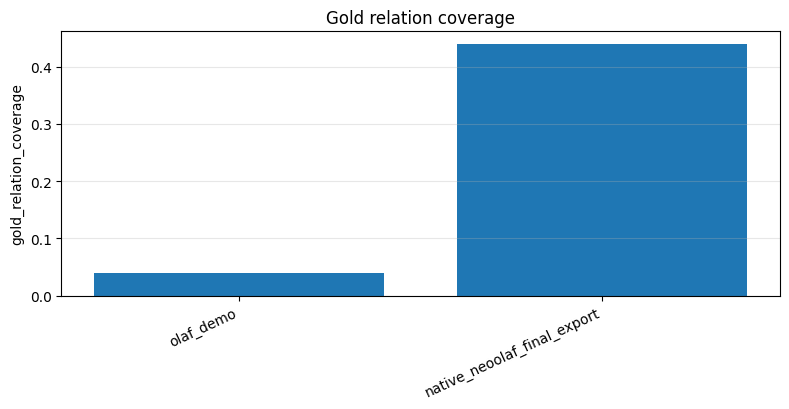

C:\Users\henri\AppData\Local\Temp\ipykernel_34408\2589412928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_compare_gold_relation_coverage.png


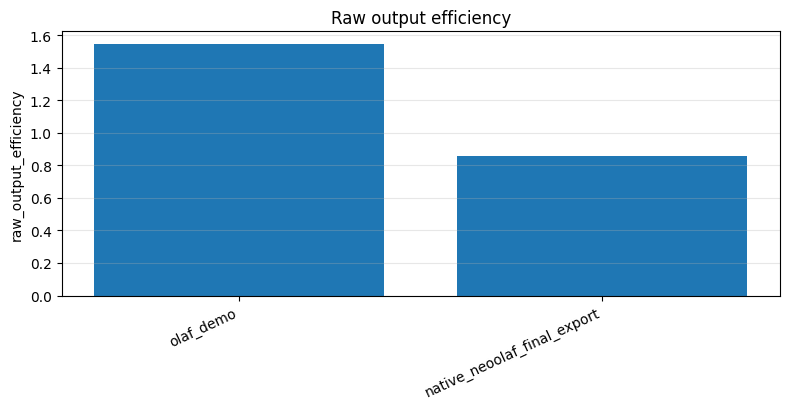

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_compare_raw_output_efficiency.png


C:\Users\henri\AppData\Local\Temp\ipykernel_34408\2589412928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")


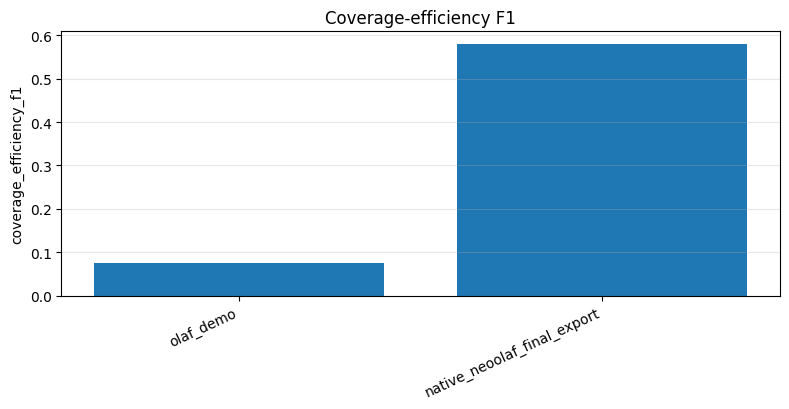

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_compare_coverage_efficiency_f1.png


C:\Users\henri\AppData\Local\Temp\ipykernel_34408\2589412928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")


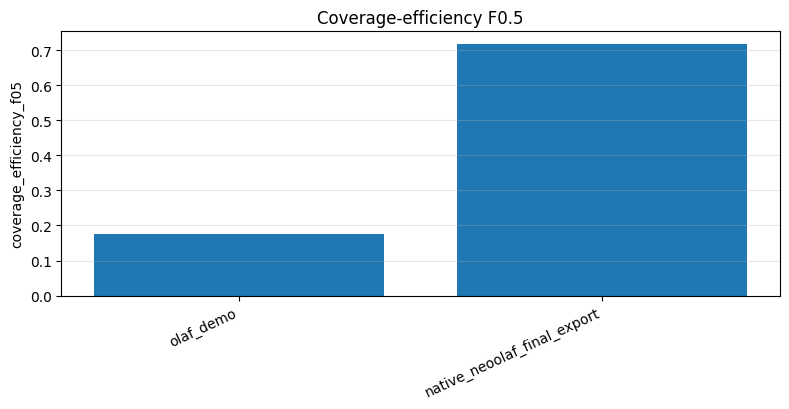

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_compare_coverage_efficiency_f05.png


C:\Users\henri\AppData\Local\Temp\ipykernel_34408\2589412928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")


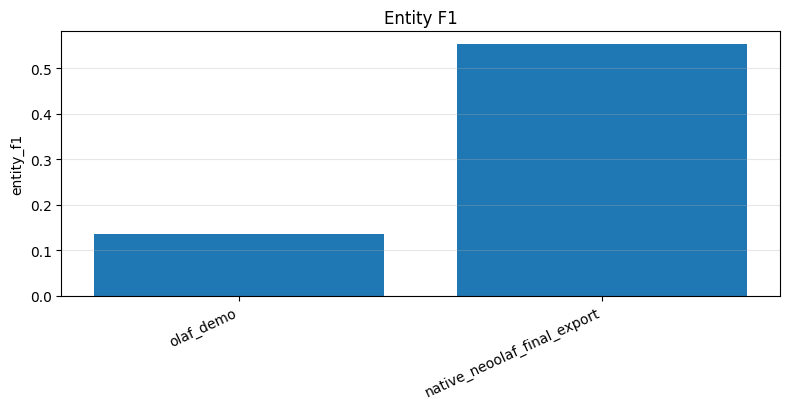

C:\Users\henri\AppData\Local\Temp\ipykernel_34408\2589412928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")


Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_compare_entity_f1.png


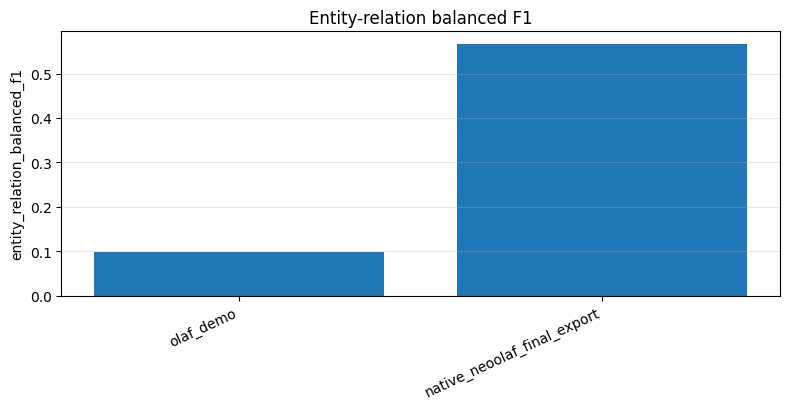

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_compare_entity_relation_balanced_f1.png


C:\Users\henri\AppData\Local\Temp\ipykernel_34408\2589412928.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")


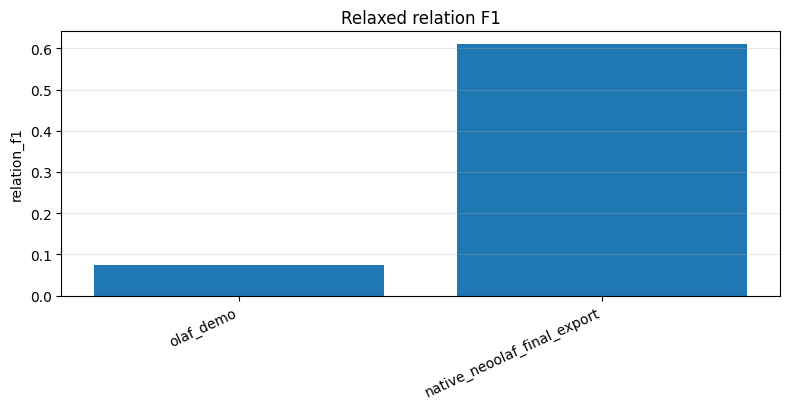

Saved: C:\Users\henri\Documents\git\post-doc\NeoOLAF\examples\XQualityMachine32\runs\olaf_demo_same_evaluator_eval\olaf_compare_relation_f1.png


In [11]:
import matplotlib.pyplot as plt

plot_df = summary_df.copy()
if not plot_df.empty:
    label_col = "series"

    metrics = [
        ("gold_relation_coverage", "Gold relation coverage"),
        ("raw_output_efficiency", "Raw output efficiency"),
        ("coverage_efficiency_f1", "Coverage-efficiency F1"),
        ("coverage_efficiency_f05", "Coverage-efficiency F0.5"),
        ("entity_f1", "Entity F1"),
        ("entity_relation_balanced_f1", "Entity-relation balanced F1"),
        ("relation_f1", "Relaxed relation F1"),
    ]

    for metric, title in metrics:
        if metric not in plot_df.columns:
            continue
        fig, ax = plt.subplots(figsize=(8, 4.2))
        ax.bar(plot_df[label_col], plot_df[metric])
        ax.set_title(title)
        ax.set_ylabel(metric)
        ax.set_xticklabels(plot_df[label_col], rotation=25, ha="right")
        ax.grid(True, axis="y", alpha=0.3)
        fig.tight_layout()
        out_path = OUTPUT_DIR / f"olaf_compare_{metric}.png"
        fig.savefig(out_path, dpi=180)
        plt.show()
        print("Saved:", out_path)
else:
    print("No rows to plot.")

## 11. Interpretation checklist

Use this checklist when reading the results:

- If `usable_triple_count` is very small, OLAF produced few evaluable triples.
- If many rows were skipped because source/target is `?`, the OLAF output file is not a clean KG extraction output.
- If relation F1 is low, check whether OLAF predicates are not in the XQuality relation vocabulary (`TRIGGERS`, `CAUSES`, `REQUIRES`, `HANDLED_BY`, `REFERENCES`).
- The `all_rows_*` metrics are stricter because they count invalid OLAF rows as output noise.
- The main fair comparison to NeoOLAF final export should use `coverage_efficiency_f1`, `coverage_efficiency_f05`, and `entity_relation_balanced_f1`, not only relaxed relation F1.